=== Reporte de Clasificación MLP ===
              precision    recall  f1-score   support

           0       0.96      1.00      0.98       147
           1       1.00      1.00      1.00       100
           2       1.00      0.99      1.00       130
           3       0.99      0.99      0.99       138
           4       0.99      0.99      0.99       142
           5       0.98      0.96      0.97        67
           6       0.99      1.00      1.00       107
           7       1.00      0.97      0.98        63
           8       1.00      0.97      0.99       106

    accuracy                           0.99      1000
   macro avg       0.99      0.99      0.99      1000
weighted avg       0.99      0.99      0.99      1000



/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


Jugada óptima sugerida (MLP): 3


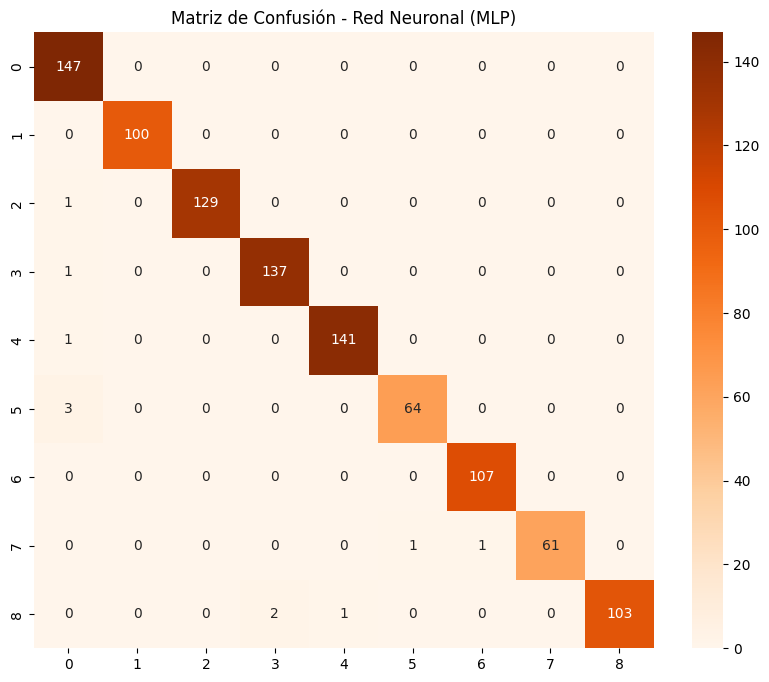

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests
from io import StringIO
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler # Importante para MLP
from sklearn.metrics import classification_report, confusion_matrix

# ==========================================
# FASE 1: SELECCIÓN DE DATOS
# ==========================================
url = "https://raw.githubusercontent.com/Hohemhein03/Dataset-Tic-Tac-Toe/refs/heads/main/dataset.csv"
raw = requests.get(url).text
raw_clean = raw.replace('"', '')
df = pd.read_csv(StringIO(raw_clean), header=None)
df.columns = [f"pos_{i}" for i in range(0, 9)] + ["turn", "best_move"]

# ==========================================
# FASE 2: PREPROCESAMIENTO
# ==========================================
mapping_tablero = {"X": 1, "x": 1, "O": -1, "o": -1, "_": 0, "b": 0}
mapping_turno = {"X": 1, "x": 1, "O": -1, "o": -1}

for col in [f"pos_{i}" for i in range(0, 9)]:
    df[col] = df[col].map(mapping_tablero).fillna(0).astype(int)

df["turn"] = df["turn"].map(mapping_turno).fillna(1).astype(int)
df["best_move"] = df["best_move"].astype(int)

# ==========================================
# FASE 3: TRANSFORMACIÓN
# ==========================================
X = df.drop(columns=["best_move"])
y = df["best_move"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Escalado de datos (Crucial para Redes Neuronales)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ==========================================
# FASE 4: MINERÍA DE DATOS
# ==========================================
# Algoritmo: MLP (Red Neuronal)
mlp = MLPClassifier(hidden_layer_sizes=(128, 64), max_iter=1000, activation='relu', solver='adam', random_state=42)
mlp.fit(X_train_scaled, y_train)

# ==========================================
# FASE 5: EVALUACIÓN
# ==========================================
y_pred = mlp.predict(X_test_scaled)

print("=== Reporte de Clasificación MLP ===")
print(classification_report(y_test, y_pred))

# Gráfico Matriz de Confusión
plt.figure(figsize=(10, 8))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Oranges')
plt.title('Matriz de Confusión - Red Neuronal (MLP)')
plt.savefig('confusion_matrix_mlp.png')

# ==========================================
# IMPLEMENTACIÓN FINAL
# ==========================================
def predecir_jugada(tablero, turno):
    t_num = [mapping_tablero.get(str(x), 0) for x in tablero]
    s_num = mapping_turno.get(turno, 1)

    # Crear array y escalar antes de predecir
    entrada = np.array(t_num + [s_num]).reshape(1, -1)
    entrada_scaled = scaler.transform(entrada) # Usar el mismo escalador

    return mlp.predict(entrada_scaled)[0]

ejemplo = ["X","X","_", "_","O","O", "_","_","_"]
turno_actual = "X"
print(f"Jugada óptima sugerida (MLP): {predecir_jugada(ejemplo, turno_actual)}")